# Week-3 Exploratory Data Analysis of Enriched Bike Rental Demand Data
## 1. Introduction
This notebook explores the enriched bike rental demand dataset produced from week-2. The dataset initially contains hourly rental demand for each location, together with time-based features, weather information, holiday indicators, and preprocessing flags.

During the data-checking process, it was found that these artificially added observations do not provide meaningful information for the current learning task. Therefore, they are identified and removed before conducting the main EDA. The subsequent analysis focuses only on hour-location observations that originate from recorded rental events.

The target variable for the cleaned analytical dataset is total_count, representing the total number of recorded bike rentals for one hour-location observation.

This notebook investigates:

the structure and quality of the enriched dataset;
the preprocessing decision used to create the analytical dataset;
the distribution of recorded bike rental demand;
demand patterns across time, location, weather, and holiday conditions;
useful candidate features for later regression modeling.

## 2. Data Overview
### 2.1 Load Dataset and Inspect Structure

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

raw_data = pd.read_csv(
    "../data/processed/final_enriched_rental_data.csv",
    parse_dates=["hour", "date"]
)

In [27]:
# overview helper
def show_results(**results):
    """Display multiple labelled notebook results in one cell."""
    
    for label, result in results.items():
        print(f"\n{label}:")
        display(result)

In [28]:
show_results(
    shape=raw_data.shape,
    columns=raw_data.columns.tolist(),
    first_rows=raw_data.head(),
)

raw_data.info()


shape:


(368424, 20)


columns:


['hour',
 'location_id',
 'direct_count',
 'registered_count',
 'total_count',
 'is_zero_filled_rental',
 'date',
 'hour_of_day',
 'day_of_week',
 'month',
 'is_weekend',
 'conditions',
 'temperature_c',
 'perceived_temperature_c',
 'humidity',
 'windspeed_kmh',
 'is_missing_weather',
 'holiday',
 'is_holiday',
 'is_workday']


first_rows:


,hour,location_id,direct_count,registered_count,total_count,is_zero_filled_rental,date,hour_of_day,day_of_week,month,is_weekend,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,is_missing_weather,holiday,is_holiday,is_workday
0,2011-01-01,0,0,0,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,0,Not a holiday,0,0
1,2011-01-01,1,0,0,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,0,Not a holiday,0,0
2,2011-01-01,2,1,0,1,0,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,0,Not a holiday,0,0
3,2011-01-01,3,0,1,1,0,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,0,Not a holiday,0,0
4,2011-01-01,4,0,2,2,0,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,0,Not a holiday,0,0


<class 'pandas.DataFrame'>
RangeIndex: 368424 entries, 0 to 368423
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   hour                     368424 non-null  datetime64[us]
 1   location_id              368424 non-null  int64         
 2   direct_count             368424 non-null  int64         
 3   registered_count         368424 non-null  int64         
 4   total_count              368424 non-null  int64         
 5   is_zero_filled_rental    368424 non-null  int64         
 6   date                     368424 non-null  datetime64[us]
 7   hour_of_day              368424 non-null  int64         
 8   day_of_week              368424 non-null  int64         
 9   month                    368424 non-null  int64         
 10  is_weekend               368424 non-null  int64         
 11  conditions               368424 non-null  str           
 12  temperature_c            36

### 2.2 Summary Statistics and Missing Values

In [29]:
show_results(
    summary_statistics=raw_data.describe(include="all").T,
    missing_values=raw_data.isna().sum(),
)


summary_statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
hour,368424,NaN,NaN,NaN,2012-01-01 11:30:00,2011-01-01 00:00:00,2011-07-02 17:45:00,2012-01-01 11:30:00,2012-07-02 05:15:00,2012-12-31 23:00:00,NaN
location_id,368424.0,NaN,NaN,NaN,10.0,0.0,5.0,10.0,15.0,20.0,6.055309
direct_count,368424.0,NaN,NaN,NaN,1.68289,0.0,0.0,1.0,2.0,28.0,2.662112
registered_count,368424.0,NaN,NaN,NaN,7.25431,0.0,1.0,5.0,11.0,59.0,7.674525
total_count,368424.0,NaN,NaN,NaN,8.9372,0.0,2.0,6.0,13.0,64.0,9.121555
is_zero_filled_rental,368424.0,NaN,NaN,NaN,0.152102,0.0,0.0,0.0,0.0,1.0,0.35912
date,368424,NaN,NaN,NaN,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 00:00:00,2012-01-01 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
hour_of_day,368424.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922196
day_of_week,368424.0,NaN,NaN,NaN,3.002736,0.0,1.0,3.0,5.0,6.0,2.003418
month,368424.0,NaN,NaN,NaN,6.519836,1.0,4.0,7.0,10.0,12.0,3.449556



missing_values:


hour                       0
location_id                0
direct_count               0
registered_count           0
total_count                0
is_zero_filled_rental      0
date                       0
hour_of_day                0
day_of_week                0
month                      0
is_weekend                 0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
is_missing_weather         0
holiday                    0
is_holiday                 0
is_workday                 0
dtype: int64

### 2.3 Target and Feature Groups
Target: total_count <br>
Rental composition: registered_count, direct_count<br>
Time-related features: hour_of_day, day_of_week, month, quarter, is_weekend, is_workday, is_holiday<br>
Location-related feature: location_id<br>
Weather-related features: conditions, temperature_c, perceived_temperature_c, humidity, windspeed_kmh<br>

### Observation 
1. The dataset covers the complete two-year period across 21 locations. Since the dataset has one row for every hour-location combination, the row count corresponds to a complete hourly-location grid.

2. The target variable, total_count, has an average value of approximately 8.94 rentals per hour-location observation and a median value of 6. The maximum value is 64. Since the mean is higher than the median, the demand distribution may be right-skewed, with a smaller number of high-demand observations. This will be examined in the target distribution section.

3. The average registered_count is substantially higher than the average direct_count, suggesting that registered rentals make up the larger share of total demand. This relationship will be examined in the rental type composition section.

## 3. Preprocessing for EDA
### 3.1 Zero_filled Rental Rows

In [30]:
zero_filled_summary = pd.DataFrame({
    "row_count": raw_data["is_zero_filled_rental"].value_counts().sort_index(),
    "percentage": (
        raw_data["is_zero_filled_rental"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
})

zero_filled_summary.index = [
    "Recorded rental demand rows",
    "Zero-filled demand rows",
]

zero_demand_check = pd.crosstab(
    raw_data["total_count"] == 0,
    raw_data["is_zero_filled_rental"],
    rownames=["total_count == 0"],
    colnames=["is_zero_filled_rental"],
)

zero_filled_target_summary = (
    raw_data.groupby("is_zero_filled_rental")["total_count"]
    .agg(["count", "mean", "median", "min", "max"])
)

zero_filled_target_summary.index = [
    "Recorded rental demand rows",
    "Zero-filled demand rows",
]

show_results(
    zero_filled_row_summary=zero_filled_summary,
    zero_demand_check=zero_demand_check,
    target_summary_by_row_type=zero_filled_target_summary,
)


zero_filled_row_summary:


,row_count,percentage
Recorded rental demand rows,312386,84.79
Zero-filled demand rows,56038,15.21



zero_demand_check:


is_zero_filled_rental,0,1
total_count == 0,,
False,312386,0
True,0,56038



target_summary_by_row_type:


,count,mean,median,min,max
Recorded rental demand rows,312386,10.540418,8.0,1,64
Zero-filled demand rows,56038,0.000000,0.0,0,0


It shows there are 56038 rows (15.21%) had no rental event in the original event data and were assigned to 0 when completing hourly-location grid.

The cross-tabulation confirms that every observation with 0 total_count is a zero-filled row, which mean rows originating from recorded rental events have a minimum demand of 1 and an average demand of approximately 10.54 rentals.

Thus these filled rows will not be used as a predictive feature when training the model, because it directly identifies rows whose target value is zero and would therefore cause data leakage.

### 3.2 Filled Weather Rows

In [35]:
location_count = raw_data["location_id"].nunique()

filled_weather_hour_count = (
    raw_data.loc[raw_data["is_missing_weather"] == 1, "hour"]
    .nunique()
)

filled_weather_row_count = raw_data["is_missing_weather"].sum()

weather_rental_fill_check = pd.crosstab(
    raw_data["is_missing_weather"],
    raw_data["is_zero_filled_rental"],
    rownames=["is_missing_weather"],
    colnames=["is_zero_filled_rental"],
    margins=True,
)

# filled_weather_hours = (
#     raw_data[raw_data["is_missing_weather"] == 1]
#     .groupby("hour")
#     .agg(
#         location_count=("location_id", "nunique"),
#         total_demand=("total_count", "sum"),
#         zero_filled_locations=("is_zero_filled_rental", "sum"),
#     )
#     .reset_index()
# )

filled_weather_hour_validation = pd.Series({
    "number_of_filled_weather_hours": len(filled_weather_hours),
    "all_hours_cover_all_locations": (
        filled_weather_hours["location_count"].eq(location_count).all()
    ),
    "all_hours_have_zero_total_demand": (
        filled_weather_hours["total_demand"].eq(0).all()
    ),
    "all_locations_are_zero_filled_in_every_hour": (
        filled_weather_hours["zero_filled_locations"].eq(location_count).all()
    ),
})

show_results(
    unique_filled_weather_hours=filled_weather_hour_count,
    affected_final_rows=filled_weather_row_count,
    number_of_locations=location_count,
    expected_affected_rows=filled_weather_hour_count * location_count,
    weather_and_rental_fill_overlap=weather_rental_fill_check,
    filled_weather_hour_validation=filled_weather_hour_validation,
    # example_filled_weather_hours=filled_weather_hours.head(10),
)


unique_filled_weather_hours:


165


affected_final_rows:


np.int64(3465)


number_of_locations:


...

3465


weather_and_rental_fill_overlap:


is_zero_filled_rental,0,1,All
is_missing_weather,,,
0,312386,52573,364959
1,0,3465,3465
All,312386,56038,368424



filled_weather_hour_validation:


number_of_filled_weather_hours                  165
all_hours_cover_all_locations                  True
all_hours_have_zero_total_demand               True
all_locations_are_zero_filled_in_every_hour    True
dtype: object

The data shows that certain 165 hours have both no originally weather recorded, nor originally rental record at any location. This is an observed overlap in data coverage.

Possible explanations could be: 1. a broader gap in data coverage during these hours; 2. a period when the bike rental system was not operating; 3. a common data-collection issue affecting both sources. These explanations cannot be confirmed from the current dataset.

For later analysis, the filled weather rows will be dropped when interpreting relationships between weather conditions and rental demand.

### 3.3 Create the Analytical Dataset

In [36]:
analysis_data = (
    raw_data[raw_data["is_zero_filled_rental"] == 0]
    .drop(columns=["is_zero_filled_rental", "is_missing_weather"])
    .copy()
)

# analysis_data_summary = pd.Series({
#     "rows_before_filtering": len(raw_data),
#     "artificial_rows_removed": int(raw_data["is_zero_filled_rental"].sum()),
#     "rows_after_filtering": len(analysis_data),
#     "columns_after_filtering": analysis_data.shape[1],
#     "minimum_target_value": int(analysis_data["total_count"].min()),
#     "remaining_missing_values": int(analysis_data.isna().sum().sum()),
# })

# analysis_data_summary

rows_before_filtering       368424
artificial_rows_removed      56038
rows_after_filtering        312386
columns_after_filtering         19
minimum_target_value             1
remaining_missing_values         0
dtype: int64

In [37]:
# validation
assert (analysis_data["total_count"] > 0).all()
assert "is_zero_filled_rental" not in analysis_data.columns
assert "is_missing_weather" not in analysis_data.columns
assert analysis_data.isna().sum().sum() == 0

analysis_data.head()

,hour,location_id,direct_count,registered_count,total_count,date,hour_of_day,day_of_week,month,is_weekend,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,holiday,is_holiday,is_workday,quarter
2,2011-01-01,2,1,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0,1
3,2011-01-01,3,0,1,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0,1
4,2011-01-01,4,0,2,2,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0,1
5,2011-01-01,5,1,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0,1
9,2011-01-01,9,0,1,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0,1


## 4. Tartge distribution


target_summary:


count    312386.000000
mean         10.540418
std           9.012750
min           1.000000
25%           3.000000
50%           8.000000
75%          15.000000
max          64.000000
Name: total_count, dtype: float64

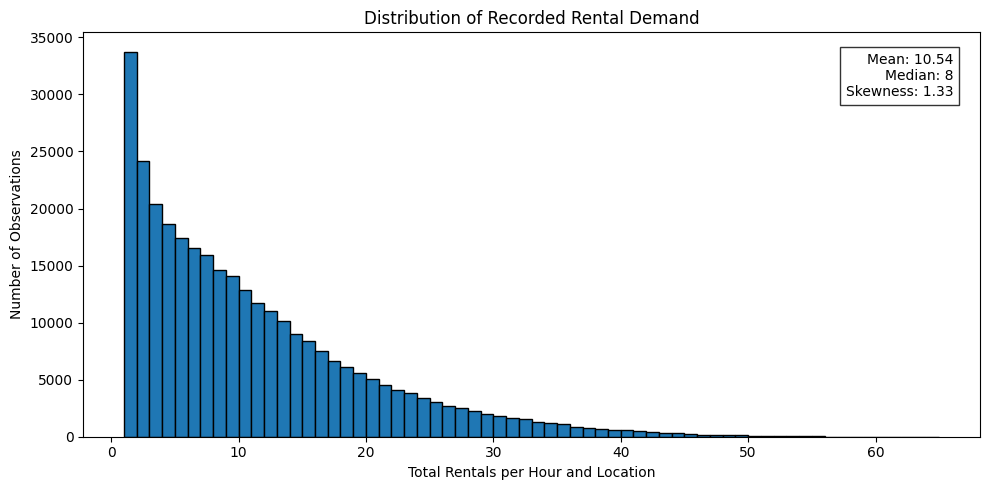

In [42]:
target_summary = analysis_data["total_count"].describe()
target_skewness = analysis_data["total_count"].skew()
maximum_demand = int(analysis_data["total_count"].max())

show_results(
    target_summary=target_summary
)

plt.figure(figsize=(10, 5))

plt.hist(
    analysis_data["total_count"],
    bins=range(1, maximum_demand + 2),
    edgecolor="black",
)

plt.title("Distribution of Recorded Rental Demand")
plt.xlabel("Total Rentals per Hour and Location")
plt.ylabel("Number of Observations")

plt.text(
    0.97,
    0.95,
    f"Mean: {target_summary['mean']:.2f}\n"
    f"Median: {target_summary['50%']:.0f}\n"
    f"Skewness: {target_skewness:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox={"facecolor": "white", "alpha": 0.8},
)

plt.tight_layout()
plt.show()

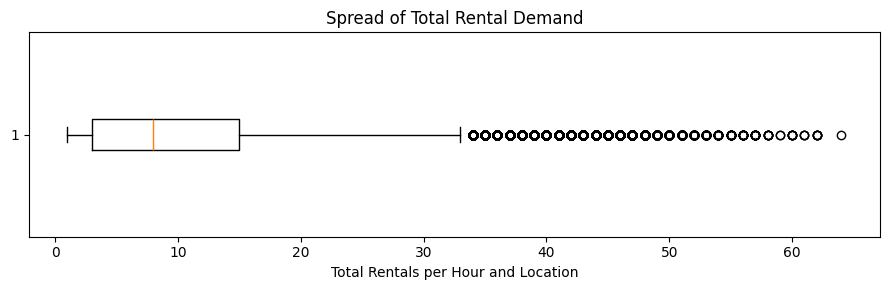

In [43]:
# high demand observasion
plt.figure(figsize=(9, 3))
plt.boxplot(
    analysis_data["total_count"],
    vert=False
)

plt.title("Spread of Total Rental Demand")
plt.xlabel("Total Rentals per Hour and Location")
plt.tight_layout()
plt.show()

In [ ]:
在实际记录到租车事件的 hour-location observations 中，
需求量如何随时间、地点、天气和节假日变化。

## 5. Reantal type composition: pie chart 或 bar chart

## 6. Time-based demand patterns
### 6.1 Average hourly demands
早晚高峰是否更高？
周末和工作日需求是否不同？
不同月份是否有季节变化？

1. hourly demand (total to show peak hour, registered/pickup to show time pattern),
Analyse average total_count, registered_count, and direct_count by hour_of_day.

registered 和 pickup 是否有不同小时模式？
line chart 或 bar chart
data.groupby("hour")[["registered_count", "pickup_count", "rental_count"]].mean()

In [16]:
# EDA helpper features
raw_data["quarter"] = raw_data["hour"].dt.quarter

show_results(
    columns_after_adding_quarter=raw_data.shape[1],
    quarter_counts=raw_data["quarter"].value_counts().sort_index(),
)

,hour,month,quarter
0,2011-01-01,1,1
1,2011-01-01,1,1
2,2011-01-01,1,1
3,2011-01-01,1,1
4,2011-01-01,1,1


### 6.2 Demand by day of week
平均总需求： 周末平均每小时需求是否更高？
不同 rental type 的平均需求：registered 和 pickup 在周末/工作日是否有不同模式？

### 6.3 Workday, weekend, and holiday comparison
一周中哪一天、哪个小时租车需求最高？
是否存在明显通勤高峰？
周末的需求峰值是否从早晚变成中午/下午？
 3. weekday-hour heatmap

### 6.4 Demand by month / quarter

## 7. Location-based demand patterns 

1. 不同 location 的总需求和平均需求
2. registered 与 direct 是否因地点不同
3. 地点差异是否只是总量不同，还是存在时间模式差异

哪些 location 的全年需求最高？
不同 location 是否有不同使用模式？
某些 location 是否更偏向 registered rentals 或 pickup rentals？
bar chart
哪些 location 是高需求 location？
需求是否集中在少数 location？
如果 location 很多，可以只画 top 10：

top_locations = (
    data.groupby("location_id")["rental_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

## 8. Weather-based demand patterns
### 8.1 Inspect weather variables

temperature, wind speed, humidity, condition
Weather analysis：不要用补出来的天气值解释需求

温度越高租车越多吗？
下雨时租车需求是否下降？
风大时是否需求下降？
不同天气 condition 下需求是否不同？

### conditian 单独分析：
1. 看原始类别：
data["conditions"].value_counts()


3. 看每种天气下的平均租车量：

data.groupby("condition")["rental_count"].agg(
    ["count", "mean", "median", "sum"]
).sort_values("mean", ascending=False)

建议重点看：
count  → 这个天气类别出现了多少次
mean   → 这种天气下平均每小时租车需求
median → 是否被极端值影响
sum    → 全年总需求

4. encoding：(before model training)
data_encoded = pd.get_dummies(
    data,
    columns=["conditions"],
    drop_first=True
)

1. single weather feature
condition → rental_count
temperature → rental_count
humidity → rental_count
wind_speed → rental_count
precipitation → rental_count


2. group features
weather_category + hour
weather_category + is_weekend
temperature_bin + condition
condition + wind_bin

The original weather condition column is a categorical text feature. It cannot be used directly by most machine learning models, but it may contain useful information about overall weather conditions, such as clear, cloudy, rainy, snowy, or foggy weather.

For EDA, I simplify the original condition labels into broader weather categories. This makes the weather patterns easier to interpret and avoids having too many sparse categories.

For modeling, this categorical feature will need to be encoded, for example using one-hot encoding. It can be used together with numerical weather features such as temperature, humidity, wind speed, and precipitation.

### 8.2 Demand by weather conditions

### 8.3 Temperature and perceived temperature

### 8.4 Humidity and wind speed

## 9. Holiday-based demand patterns

节假日租车需求是否和平时不同？
节假日 registered 和 pickup 的比例是否变化？

## 10. Demand pattern heatmaps


weekday × hour 的 average rental demand heatmap
location_id × hour
temperature_bin × hour
weather_condition × hour

In [ ]:
## condition encoding: 
numeric features & categorical features

## 11. Findings and further modeling

In [ ]:
FEATURES = ["hour", "location_id", "date", "hour_of_day", "day_of_week", "mont", "is_weekend", "conditions",]